# Pre-processing di un Dataset di Rilevazione del Tumore al Seno

In questo progetto viene sviluppata una pipeline di preprocessing
per preparare un dataset relativo alla rilevazione del tumore al seno.
L'obiettivo è pulire e trasformare i dati in modo automatico così
da ottenere un dataset pronto per l’utilizzo nei modelli di
machine learning.
Attraverso l’utilizzo di Pipeline e ColumnTransformer di scikit-learn
vengono gestiti valori mancanti, trasformazioni delle variabili,
encoding delle categorie e tecniche di riduzione della dimensionalità.

In [ ]:
# Import principali
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder,
    StandardScaler, MinMaxScaler,
    KBinsDiscretizer, PowerTransformer
)
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif

import joblib
import matplotlib.pyplot as plt

In [ ]:
# 1) Caricamento dataset

# Carichiamo il dataset da CSV e controlliamo dimensioni e prime righe
df = pd.read_csv("/content/sample_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,NaN,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.14710,0.2419,0.07871,...,17.33,NaN,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,NaN,NaN,0.0869,0.07017,NaN,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,NaN,0
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,NaN,NaN,NaN,0.05999,...,25.53,NaN,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,NaN,0.2597,0.09744,...,26.50,NaN,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,NaN,NaN,NaN,0.1328,0.1980,NaN,0.1809,NaN,...,16.67,152.2,1575.0,0.1374,NaN,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# Separiamo feature e target (la colonna target non entra nelle pipeline)
X = df.drop("target", axis=1)
y = df["target"]

print("Distribuzione target:")
print(y.value_counts(dropna=False))

Distribuzione target:
target
1    357
0    212
Name: count, dtype: int64


In [ ]:
# 2) Mini EDA: missing values + tipi colonne

# Missing values per colonna
missing = X.isna().sum().sort_values(ascending=False)
print("Missing values (top 10):")
print(missing.head(10))

# Tipi di colonne
print("\nTipi colonne:")
print(X.dtypes.value_counts())

Missing values (top 10):
concavity error            190
perimeter error            188
mean concave points        187
mean smoothness            185
mean area                  166
worst symmetry             159
fractal dimension error    157
worst texture              155
texture error              135
mean concavity             130
dtype: int64

Tipi colonne:
float64    29
object      1
Name: count, dtype: int64


In [ ]:
# Identifichiamo colonne numeriche e categoriche
num_cols = X.select_dtypes(exclude=["object", "category", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numero colonne numeriche:", len(num_cols))
print("Numero colonne categoriche:", len(cat_cols))
print("\nEsempio numeriche:", num_cols[:5])
print("Esempio categoriche:", cat_cols[:5])

Numero colonne numeriche: 29
Numero colonne categoriche: 1

Esempio numeriche: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
Esempio categoriche: ['area error']


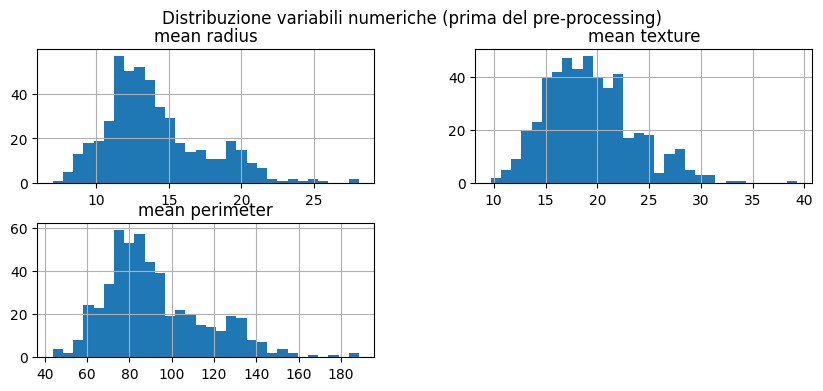

In [ ]:
# 3) EDA: distribuzione variabili numeriche

# Scegliamo 3 colonne numeriche come esempio, se sono disponibili
plot_cols = num_cols[:3]

if len(plot_cols) == 0:
    print("Nessuna colonna numerica trovata.")
else:
    X[plot_cols].hist(bins=30, figsize=(10,4))
    plt.suptitle("Distribuzione variabili numeriche (prima del pre-processing)")
    plt.show()

In [ ]:
# 4) Pipeline 1 — Solo record con target=1

# Richieste:
# - Missing: diverso tra variabili simmetriche e asimmetriche (qui media vs mediana)
# - Simmetrizzazione variabili asimmetriche (PowerTransformer Yeo-Johnson)
# - One-Hot Encoding categoriche
# - StandardScaler numeriche

# Filtriamo i record positivi (target=1)
X_pos = X[y == 1].copy()
y_pos = y[y == 1].copy()

print("Shape X_pos:", X_pos.shape)

Shape X_pos: (357, 30)


In [ ]:
# Separiamo numeriche simmetriche/asimmetriche usando skewness
skew = X_pos[num_cols].skew(numeric_only=True).abs().sort_values(ascending=False)
print("Skewness (top 10):")
print(skew.head(10))

SKEW_THRESHOLD = 1.0
asym_cols = skew[skew > SKEW_THRESHOLD].index.tolist()
sym_cols = [c for c in num_cols if c not in asym_cols]

print("\nNumeriche asimmetriche:", len(asym_cols))
print("Numeriche simmetriche:", len(sym_cols))

Skewness (top 10):
concavity error            4.987570
fractal dimension error    4.454066
mean concavity             3.534439
worst concavity            2.724197
compactness error          2.314896
concave points error       2.281630
mean fractal dimension     1.755398
radius error               1.565399
worst fractal dimension    1.509955
smoothness error           1.434353
dtype: float64

Numeriche asimmetriche: 17
Numeriche simmetriche: 12


In [ ]:
# Pipeline numeriche simmetriche: imputazione media + standardizzazione
sym_num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Pipeline numeriche asimmetriche: imputazione mediana + simmetrizzazione + standardizzazione
asym_num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

# Pipeline categoriche: imputazione moda + one-hot
cat_pipe_1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer: applichiamo trasformazioni a gruppi diversi di colonne
preprocess_1 = ColumnTransformer(
    transformers=[
        ("sym_num", sym_num_pipe, sym_cols),
        ("asym_num", asym_num_pipe, asym_cols),
        ("cat", cat_pipe_1, cat_cols)
    ],
    remainder="drop"
)

# Oggetto finale della pipeline 1
pipeline_1 = Pipeline(steps=[
    ("preprocess", preprocess_1)
])

# Output visibile: dimensione trasformata
X_pos_t = pipeline_1.fit_transform(X_pos, y_pos)
print("Pipeline 1 -> shape trasformato (target=1):", X_pos_t.shape)

Pipeline 1 -> shape trasformato (target=1): (357, 30)


In [ ]:
# EDA (prima/dopo) — esempio su variabili asimmetriche (pipeline 1)

# Mostriamo skewness prima e dopo la trasformazione di simmetrizzazione, solo parte numerica asimmetrica
# Calcoliamo la skewness per dividere numeriche simmetriche vs asimmetriche

# Se abbiamo almeno 1 colonna asimmetrica, mostriamo confronto skewness prima/dopo su quelle
if len(asym_cols) == 0:
    print("Nessuna colonna asimmetrica sopra soglia; salto confronto skewness.")
else:
    # Applichiamo solo la parte power transformer (senza scaler) per vedere l'effetto sulla distribuzione
    tmp_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("power", PowerTransformer(method="yeo-johnson"))
    ])
    before_skew = X_pos[asym_cols].skew(numeric_only=True)
    after_arr = tmp_pipe.fit_transform(X_pos[asym_cols])
    after_df = pd.DataFrame(after_arr, columns=asym_cols)
    after_skew = after_df.skew(numeric_only=True)

    compare = pd.DataFrame({"skew_before": before_skew, "skew_after": after_skew}).sort_values("skew_before", key=lambda s: s.abs(), ascending=False)
    compare.head(10)

In [ ]:
# 5) Pipeline 2 — Tutti i record

# Richieste:
# - Missing values
# - Discretizzazione numeriche in 20 bin
# - Ordinal encoding categoriche (ordine naturale alfabetico)
# - Selezione delle 5 variabili più informative rispetto al target

# Preprocessing numeriche: imputazione + binning 20 bin
num_pipe_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("binning", KBinsDiscretizer(n_bins=20, encode="ordinal", strategy="quantile"))
])

# Preprocessing categoriche: imputazione + ordinal encoding
cat_pipe_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocess_2 = ColumnTransformer(
    transformers=[
        ("num", num_pipe_2, num_cols),
        ("cat", cat_pipe_2, cat_cols)
    ],
    remainder="drop"
)

# Pipeline 2 completa: preprocessing + selezione top 5 feature
pipeline_2 = Pipeline(steps=[
    ("preprocess", preprocess_2),
    ("select_k", SelectKBest(score_func=mutual_info_classif, k=5))
])

# Qui compare un warning perché alcune variabili hanno molti valori uguali o distribuzioni poco variabili
X2 = pipeline_2.fit_transform(X, y)
print("Pipeline 2 -> shape trasformato (tutti i record, top 5):", X2.shape)

Pipeline 2 -> shape trasformato (tutti i record, top 5): (569, 5)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306

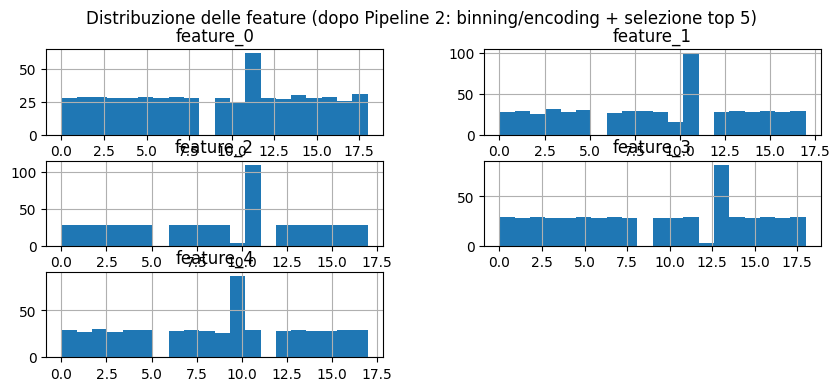

In [ ]:
# EDA (prima/dopo) — distribuzione feature dopo discretizzazione + selezione
# Visualizziamo la distribuzione di alcune variabili numeriche PRIMA del pre-processing

# Convertiamo le 5 feature finali in DataFrame per visualizzare distribuzioni (solo per EDA)
X2_df = pd.DataFrame(X2, columns=[f"feature_{i}" for i in range(X2.shape[1])])

X2_df.hist(bins=20, figsize=(10,4))
plt.suptitle("Distribuzione delle feature (dopo Pipeline 2: binning/encoding + selezione top 5)")
plt.show()

In [ ]:
# 6) Pipeline 3 — Solo variabili numeriche

# Richieste:
# - Missing values numeriche
# - PCA mantenendo 80% varianza
# - Simmetrizzazione (PowerTransformer)
# - Normalizzazione 0-1 (MinMaxScaler)

X_num = X[num_cols].copy()
print("Shape X_num:", X_num.shape)

Shape X_num: (569, 29)


In [ ]:
# Usiamo PowerTransformer (Yeo-Johnson) per rendere più simmetriche le variabili asimmetriche

pipeline_3 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler_before_pca", StandardScaler()),
    ("pca", PCA(n_components=0.80, random_state=42)),
    ("minmax", MinMaxScaler())
])

X3 = pipeline_3.fit_transform(X_num, y)
print("Pipeline 3 -> shape trasformato (solo numeriche):", X3.shape)

Pipeline 3 -> shape trasformato (solo numeriche): (569, 8)


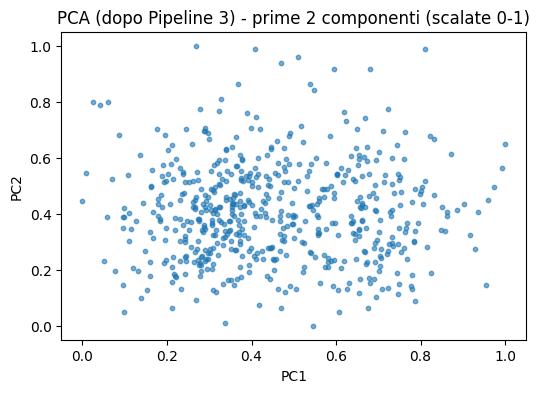

In [ ]:
# EDA (prima/dopo) — PCA (prime 2 componenti come esempio)

if X3.shape[1] >= 2:
    plt.figure(figsize=(6,4))
    plt.scatter(X3[:,0], X3[:,1], s=10, alpha=0.6)
    plt.title("PCA (dopo Pipeline 3) - prime 2 componenti (scalate 0-1)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()
else:
    print("PCA ha prodotto meno di 2 componenti, salto scatter.")

In [ ]:
# 7) Oggetto finale + esportazione
# Salviamo l’oggetto finale (tutte le pipeline) su file binario per riuso futuro

# Oggetto finale che raggruppa tutte le pipeline
final_preprocessing = {
    "pipeline_1_target1": pipeline_1,
    "pipeline_2_all_top5": pipeline_2,
    "pipeline_3_numeric_pca": pipeline_3
}

# Salvataggio su file binario
joblib.dump(final_preprocessing, "preprocessing_pipelines.joblib")

print("Salvato: preprocessing_pipelines.joblib")


Salvato: preprocessing_pipelines.joblib


In [ ]:
# 8) Test rapido di caricamento (per mostrare output in notebook)

# Carichiamo l'oggetto salvato e verifichiamo che contenga le tre pipeline
# Testiamo il caricamento del file binario per verificare che sia utilizzabile

loaded = joblib.load("preprocessing_pipelines.joblib")
print("Chiavi oggetto caricato:", list(loaded.keys()))
print("Tipo pipeline 2:", type(loaded["pipeline_2_all_top5"]))


Chiavi oggetto caricato: ['pipeline_1_target1', 'pipeline_2_all_top5', 'pipeline_3_numeric_pca']
Tipo pipeline 2: <class 'sklearn.pipeline.Pipeline'>


In [ ]:
# Commento finale
# In questo notebook ho creato 3 pipeline distinte per tre esigenze diverse (solo target=1, tutti i record, solo numeriche con PCA)
# Ho mostrato alcuni output e grafici per verificare che le trasformazioni abbiano l’effetto desiderato (come gestione missing, riduzione skewness, discretizzazione, riduzione dimensionale)
# Il risultato finale è un oggetto salvato su file che contiene tutte le pipeline pronte da riutilizzare